In [1]:
# IMPORTAR LIBRERÍAS

import os
import warnings
from getpass import getpass
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from supabase import create_client, Client
from IPython.display import display

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 14

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [2]:
# CONEXIÓN CON SUPABASE

ruta_actual = Path.cwd()

if (ruta_actual.parent / ".env").exists():
    ROOT_DIR = ruta_actual.parent

elif (ruta_actual / ".env").exists():
    ROOT_DIR = ruta_actual

else:
    raise FileNotFoundError(
        "No se encontró el archivo .env. "
        "Verifica que el notebook esté dentro de la carpeta Notebook."
    )

load_dotenv(ROOT_DIR / ".env")

SUPABASE_URL = "https://zytfjhwdrpbmkkrdbagj.supabase.co"
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

if not SUPABASE_KEY:
    raise ValueError(
        "No se encontró SUPABASE_KEY dentro del archivo .env."
    )

supabase: Client = create_client(
    SUPABASE_URL,
    SUPABASE_KEY
)

print("Conexión con Supabase configurada correctamente.")

Conexión con Supabase configurada correctamente.


In [3]:
# INICIAR SESIÓN COMO USUARIO

correo_usuario = input("Correo del usuario: ").strip()
password_usuario = getpass("Contraseña: ")

response = supabase.auth.sign_in_with_password({
    "email": correo_usuario,
    "password": password_usuario
})

usuario_id = response.user.id

print(f"Sesión iniciada correctamente como: {response.user.email}")

Sesión iniciada correctamente como: luisflores@gmail.com


In [4]:
# CARGAR INFORMACIÓN DEL USUARIO

def consultar_tabla(nombre_tabla, columnas="*"):
    respuesta = (
        supabase
        .table(nombre_tabla)
        .select(columnas)
        .execute()
    )

    return pd.DataFrame(respuesta.data or [])


df_participante = consultar_tabla(
    "participantes",
    (
        "id_participante, id_usuario, nombre_completo, edad, "
        "genero, ciudad, nivel_educativo, fecha_registro"
    )
)

df_participante = df_participante[
    df_participante["id_usuario"] == usuario_id
].copy()

if df_participante.empty:
    raise ValueError(
        "No se encontró un perfil de participante asociado a esta cuenta."
    )

participante_id = df_participante.iloc[0]["id_participante"]
nombre_usuario = df_participante.iloc[0]["nombre_completo"]

df_encuestas = consultar_tabla(
    "encuestas",
    "id_encuesta, id_participante, fecha_aplicacion, estado"
)

df_encuestas = df_encuestas[
    df_encuestas["id_participante"] == participante_id
].copy()

if df_encuestas.empty:
    raise ValueError(
        "El usuario todavía no ha completado una encuesta."
    )

df_respuestas = consultar_tabla(
    "respuestas_encuesta",
    (
        "id_respuesta, id_encuesta, usa_misma_contrasena, "
        "usa_wifi_publico, reconoce_phishing, usa_doble_factor, "
        "tiene_antivirus, actualiza_contrasenas, "
        "comparte_info_redes, nivel_conocimiento"
    )
)

df_resultados = consultar_tabla(
    "resultados_riesgo",
    (
        "id_resultado, id_encuesta, puntaje_riesgo, "
        "clasificacion_riesgo, observacion, fecha_calculo"
    )
)

df = (
    df_encuestas
    .merge(
        df_respuestas,
        on="id_encuesta",
        how="left"
    )
    .merge(
        df_resultados,
        on="id_encuesta",
        how="left"
    )
)

df["fecha_aplicacion"] = pd.to_datetime(
    df["fecha_aplicacion"],
    errors="coerce"
)

df["puntaje_riesgo"] = pd.to_numeric(
    df["puntaje_riesgo"],
    errors="coerce"
)

df["clasificacion_riesgo"] = (
    df["clasificacion_riesgo"]
    .astype("string")
    .str.strip()
    .str.lower()
)

df = df.sort_values(
    "fecha_aplicacion"
).reset_index(drop=True)

ultima_encuesta = df.iloc[-1]

print(f"Usuario analizado: {nombre_usuario}")
print(f"Encuestas registradas: {len(df)}")
print()
display(df)

Usuario analizado: Luis Flores
Encuestas registradas: 1



,id_encuesta,id_participante,fecha_aplicacion,estado,id_respuesta,usa_misma_contrasena,usa_wifi_publico,reconoce_phishing,usa_doble_factor,tiene_antivirus,actualiza_contrasenas,comparte_info_redes,nivel_conocimiento,id_resultado,puntaje_riesgo,clasificacion_riesgo,observacion,fecha_calculo
0,654564d0-4f0c-47cd-830c-f196f1085bf6,b1ab8762-17f0-491a-bb21-30521c4449e1,2026-06-07 01:28:55.609422,completada,db3b5a1f-c844-431a-a14d-41b7c148ca95,True,True,a_veces,False,False,False,False,medio,b14c84ed-5f32-438c-abf6-316d1be5d2cd,9.0,alto,Se identificaron varios hábitos inseguros. Es ...,2026-06-07T01:28:55.998395


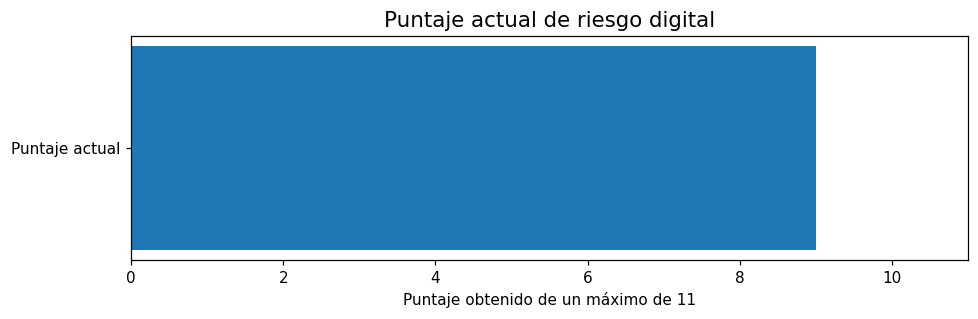

Puntaje actual: 9 de 11


In [5]:
# GRÁFICA 1: PUNTAJE ACTUAL DE RIESGO

puntaje_actual = int(
    ultima_encuesta["puntaje_riesgo"]
)

plt.figure(figsize=(9, 3))

plt.barh(
    ["Puntaje actual"],
    [puntaje_actual]
)

plt.xlim(0, 11)
plt.title("Puntaje actual de riesgo digital")
plt.xlabel("Puntaje obtenido de un máximo de 11")
plt.tight_layout()

plt.savefig(
    ROOT_DIR / "Notebook" / "usuario_actual_grafica1_puntaje.png",
    bbox_inches="tight"
)

plt.show()

print(f"Puntaje actual: {puntaje_actual} de 11")


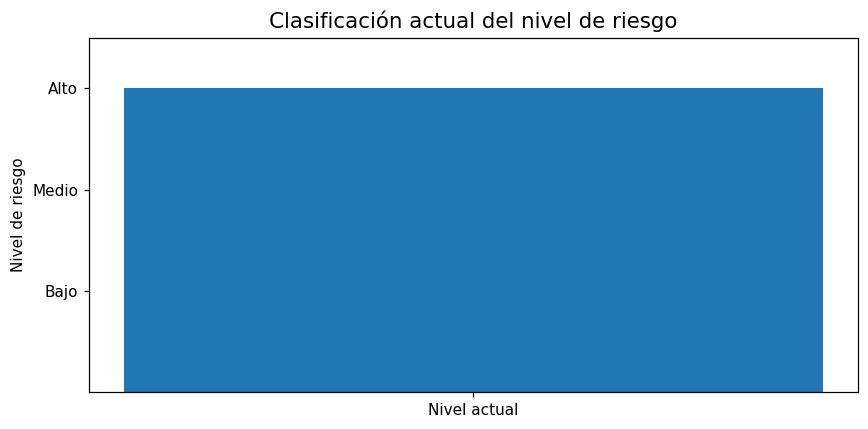

Clasificación actual: Alto


In [6]:
# GRÁFICA 2: CLASIFICACIÓN ACTUAL DEL RIESGO

escala_riesgo = {
    "bajo": 1,
    "medio": 2,
    "alto": 3
}

clasificacion_actual = (
    str(
        ultima_encuesta[
            "clasificacion_riesgo"
        ]
    )
    .strip()
    .lower()
)

valor_riesgo = escala_riesgo.get(
    clasificacion_actual,
    0
)

plt.figure(figsize=(8, 4))

plt.bar(
    ["Nivel actual"],
    [valor_riesgo]
)

plt.ylim(0, 3.5)
plt.yticks(
    [1, 2, 3],
    ["Bajo", "Medio", "Alto"]
)
plt.title("Clasificación actual del nivel de riesgo")
plt.ylabel("Nivel de riesgo")
plt.tight_layout()

plt.savefig(
    ROOT_DIR / "Notebook" / "usuario_actual_grafica2_clasificacion.png",
    bbox_inches="tight"
)

plt.show()

print(
    f"Clasificación actual: "
    f"{clasificacion_actual.title()}"
)


,Hábito inseguro,Detectado
0,Reutiliza contraseñas,1
1,Usa Wi-Fi público,1
2,No reconoce phishing,1
3,No usa doble factor,1
4,No tiene antivirus,1
5,No actualiza contraseñas,1
6,Comparte información en redes,0


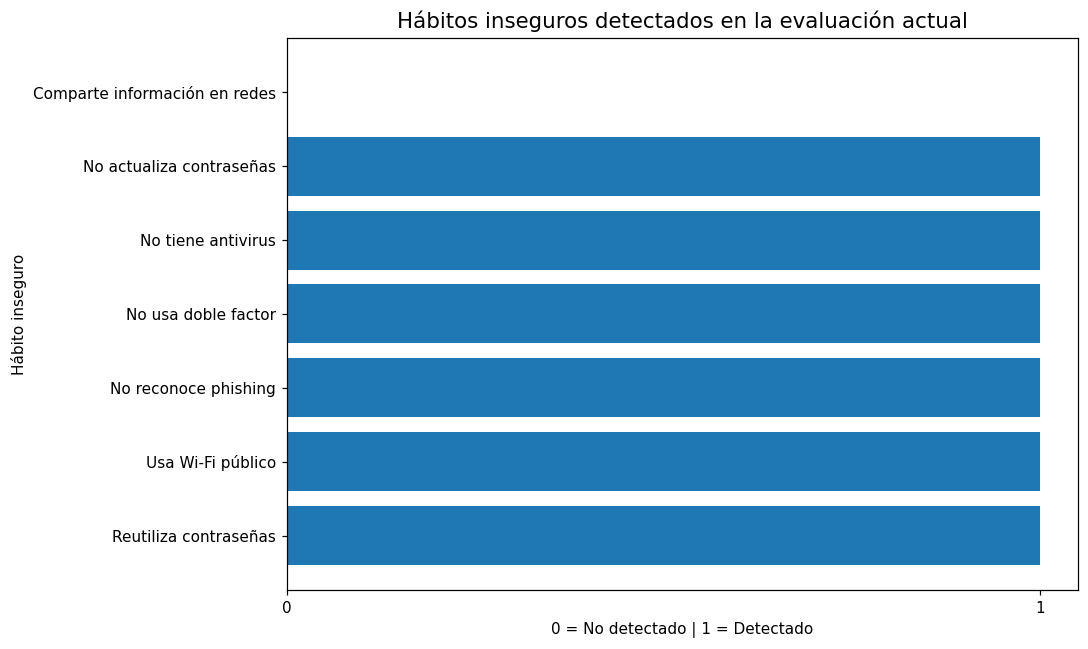

In [7]:
# GRÁFICA 3: HÁBITOS INSEGUROS DETECTADOS

habitos_inseguros = {
    "Reutiliza contraseñas": int(
        ultima_encuesta["usa_misma_contrasena"] == True
    ),
    "Usa Wi-Fi público": int(
        ultima_encuesta["usa_wifi_publico"] == True
    ),
    "No reconoce phishing": int(
        ultima_encuesta["reconoce_phishing"] != "si"
    ),
    "No usa doble factor": int(
        ultima_encuesta["usa_doble_factor"] == False
    ),
    "No tiene antivirus": int(
        ultima_encuesta["tiene_antivirus"] == False
    ),
    "No actualiza contraseñas": int(
        ultima_encuesta["actualiza_contrasenas"] == False
    ),
    "Comparte información en redes": int(
        ultima_encuesta["comparte_info_redes"] == True
    )
}

df_habitos_inseguros = pd.DataFrame(
    list(
        habitos_inseguros.items()
    ),
    columns=[
        "Hábito inseguro",
        "Detectado"
    ]
)

display(df_habitos_inseguros)

plt.figure(figsize=(10, 6))

plt.barh(
    df_habitos_inseguros["Hábito inseguro"],
    df_habitos_inseguros["Detectado"]
)

plt.title("Hábitos inseguros detectados en la evaluación actual")
plt.xlabel("0 = No detectado | 1 = Detectado")
plt.ylabel("Hábito inseguro")
plt.xticks([0, 1])
plt.tight_layout()

plt.savefig(
    ROOT_DIR / "Notebook" / "usuario_actual_grafica3_habitos_inseguros.png",
    bbox_inches="tight"
)

plt.show()


,Práctica segura,Cumple
0,Usa contraseñas diferentes,0
1,Evita Wi-Fi público,0
2,Reconoce phishing,0
3,Usa doble factor,0
4,Tiene antivirus,0
5,Actualiza contraseñas,0
6,Cuida su información en redes,1


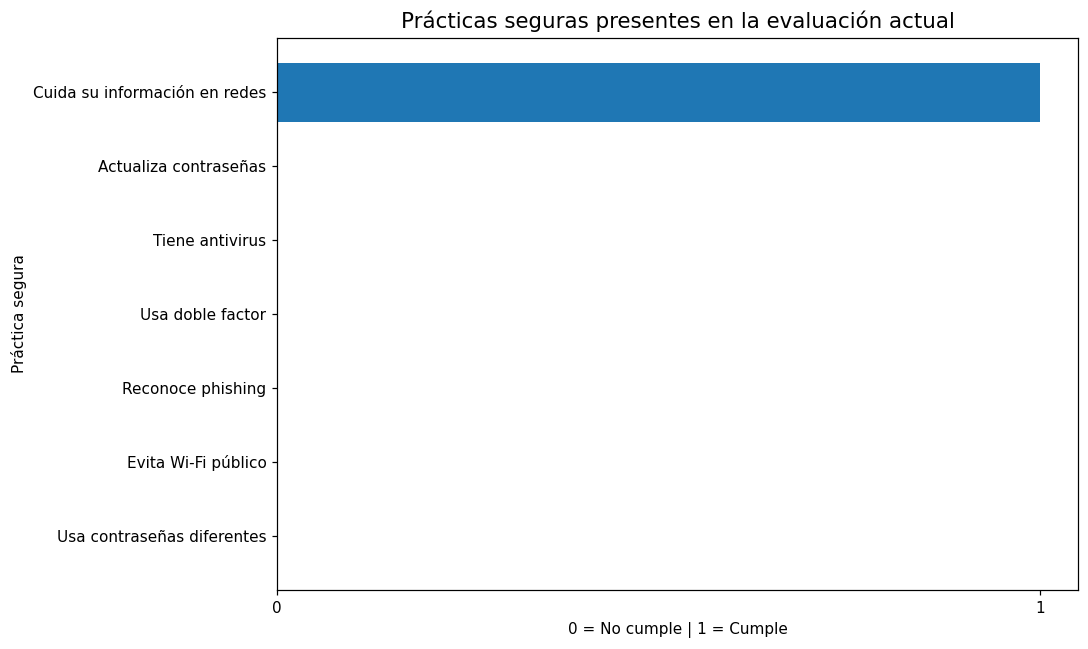

In [8]:
# GRÁFICA 4: PRÁCTICAS SEGURAS ACTUALES

practicas_seguras = {
    "Usa contraseñas diferentes": int(
        ultima_encuesta["usa_misma_contrasena"] == False
    ),
    "Evita Wi-Fi público": int(
        ultima_encuesta["usa_wifi_publico"] == False
    ),
    "Reconoce phishing": int(
        ultima_encuesta["reconoce_phishing"] == "si"
    ),
    "Usa doble factor": int(
        ultima_encuesta["usa_doble_factor"] == True
    ),
    "Tiene antivirus": int(
        ultima_encuesta["tiene_antivirus"] == True
    ),
    "Actualiza contraseñas": int(
        ultima_encuesta["actualiza_contrasenas"] == True
    ),
    "Cuida su información en redes": int(
        ultima_encuesta["comparte_info_redes"] == False
    )
}

df_practicas_seguras = pd.DataFrame(
    list(
        practicas_seguras.items()
    ),
    columns=[
        "Práctica segura",
        "Cumple"
    ]
)

display(df_practicas_seguras)

plt.figure(figsize=(10, 6))

plt.barh(
    df_practicas_seguras["Práctica segura"],
    df_practicas_seguras["Cumple"]
)

plt.title("Prácticas seguras presentes en la evaluación actual")
plt.xlabel("0 = No cumple | 1 = Cumple")
plt.ylabel("Práctica segura")
plt.xticks([0, 1])
plt.tight_layout()

plt.savefig(
    ROOT_DIR / "Notebook" / "usuario_actual_grafica4_practicas_seguras.png",
    bbox_inches="tight"
)

plt.show()


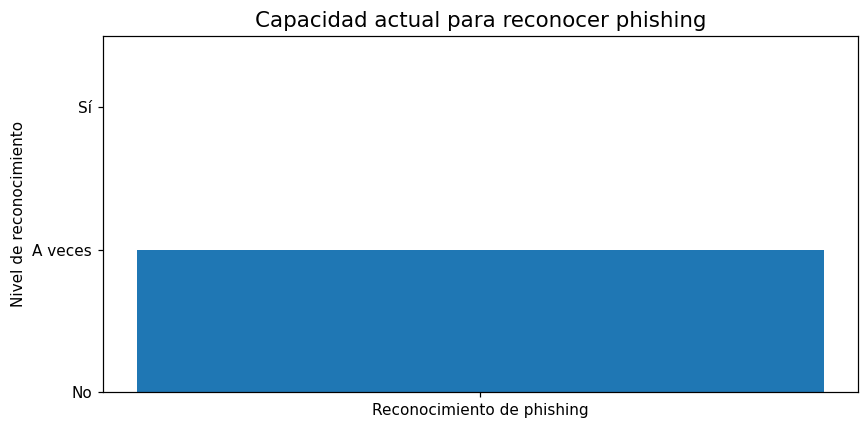

Respuesta actual: A Veces


In [9]:
# GRÁFICA 5: RECONOCIMIENTO DE PHISHING

escala_phishing = {
    "no": 0,
    "a_veces": 1,
    "si": 2
}

respuesta_phishing = (
    str(
        ultima_encuesta[
            "reconoce_phishing"
        ]
    )
    .strip()
    .lower()
)

valor_phishing = escala_phishing.get(
    respuesta_phishing,
    0
)

plt.figure(figsize=(8, 4))

plt.bar(
    ["Reconocimiento de phishing"],
    [valor_phishing]
)

plt.ylim(0, 2.5)
plt.yticks(
    [0, 1, 2],
    ["No", "A veces", "Sí"]
)
plt.title("Capacidad actual para reconocer phishing")
plt.ylabel("Nivel de reconocimiento")
plt.tight_layout()

plt.savefig(
    ROOT_DIR / "Notebook" / "usuario_actual_grafica5_phishing.png",
    bbox_inches="tight"
)

plt.show()

print(
    f"Respuesta actual: "
    f"{respuesta_phishing.replace('_', ' ').title()}"
)


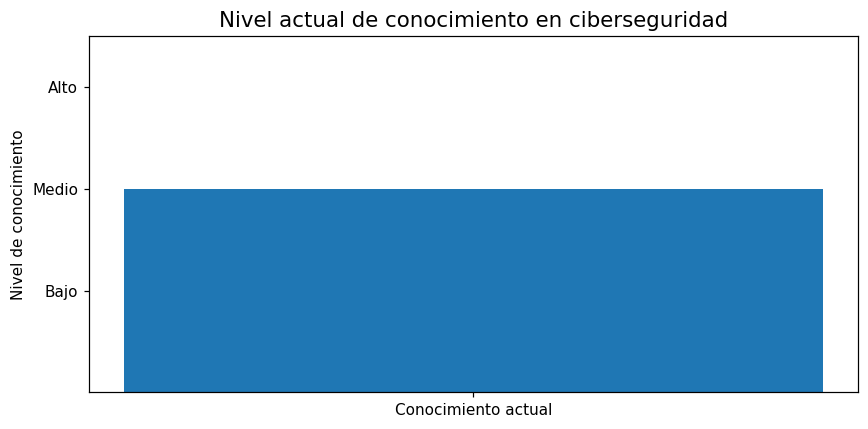

Nivel de conocimiento actual: Medio


In [10]:
# GRÁFICA 6: NIVEL DE CONOCIMIENTO

escala_conocimiento = {
    "bajo": 1,
    "medio": 2,
    "alto": 3
}

nivel_conocimiento = (
    str(
        ultima_encuesta[
            "nivel_conocimiento"
        ]
    )
    .strip()
    .lower()
)

valor_conocimiento = escala_conocimiento.get(
    nivel_conocimiento,
    0
)

plt.figure(figsize=(8, 4))

plt.bar(
    ["Conocimiento actual"],
    [valor_conocimiento]
)

plt.ylim(0, 3.5)
plt.yticks(
    [1, 2, 3],
    ["Bajo", "Medio", "Alto"]
)
plt.title("Nivel actual de conocimiento en ciberseguridad")
plt.ylabel("Nivel de conocimiento")
plt.tight_layout()

plt.savefig(
    ROOT_DIR / "Notebook" / "usuario_actual_grafica6_conocimiento.png",
    bbox_inches="tight"
)

plt.show()

print(
    f"Nivel de conocimiento actual: "
    f"{nivel_conocimiento.title()}"
)


,Tipo,Cantidad
0,Prácticas seguras,1
1,Hábitos de riesgo,6


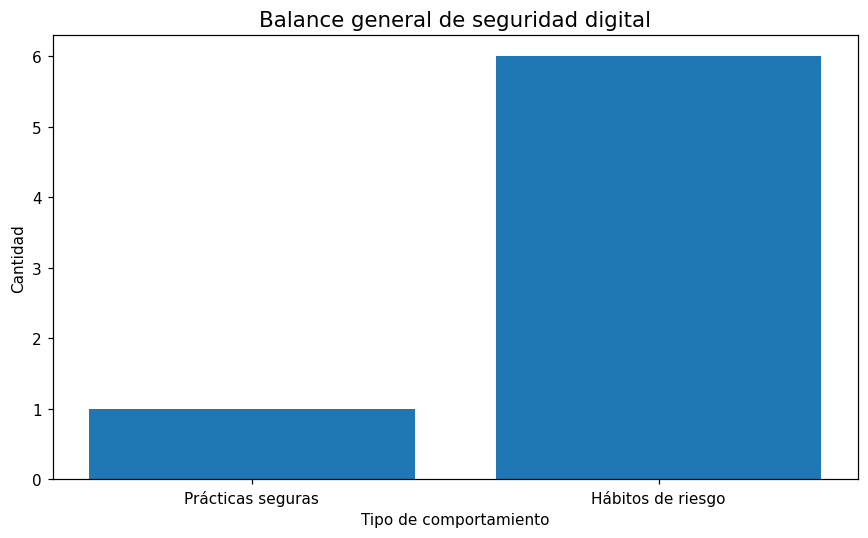

In [11]:
# GRÁFICA 7: BALANCE GENERAL

cantidad_riesgos = sum(
    habitos_inseguros.values()
)

cantidad_seguras = sum(
    practicas_seguras.values()
)

df_balance = pd.DataFrame({
    "Tipo": [
        "Prácticas seguras",
        "Hábitos de riesgo"
    ],
    "Cantidad": [
        cantidad_seguras,
        cantidad_riesgos
    ]
})

display(df_balance)

plt.figure(figsize=(8, 5))

plt.bar(
    df_balance["Tipo"],
    df_balance["Cantidad"]
)

plt.title("Balance general de seguridad digital")
plt.xlabel("Tipo de comportamiento")
plt.ylabel("Cantidad")
plt.tight_layout()

plt.savefig(
    ROOT_DIR / "Notebook" / "usuario_actual_grafica7_balance.png",
    bbox_inches="tight"
)

plt.show()
